# Does It Rain More in Seattle, WA than in San Francisco, CA?

## Introduction

Seattle has a reputation as one of the rainiest cities in the United States. San Francisco is another Pacific coast city that many people picture as foggy and wet. This project asks a simple question: **does it rain more in Seattle than in San Francisco?**

"Rain more" can mean different things, so I look at it in three ways:

1. **Amount:** how much precipitation (in inches) falls on an average day.
2. **Frequency:** on what share of days there is any precipitation at all.
3. **Seasonality:** whether the difference holds in every month of the year or only in some months.

I follow the data science methodology: inspect the data, fix data types, remove what is not needed, handle missing values, join the two cities, reshape the data into tidy form, create derived variables, explore the data with summaries and graphs, and then test the differences statistically. Each code section is preceded by a description of its purpose and followed by an interpretation of its output.

## Data sources

Both files contain daily precipitation records from NOAA's National Centers for Environmental Information (NCEI) Climate Data Online service, which distributes the Global Historical Climatology Network daily (GHCN-Daily) dataset.

* Data search portal: https://www.ncei.noaa.gov/cdo-web/search
* GHCN-Daily overview: https://www.ncei.noaa.gov/products/land-based-station/global-historical-climatology-network-daily

| File | Station | Station ID |
|---|---|---|
| `seattle_rain.csv` | SEATTLE 2.1 ESE, WA US | US1WAKG0225 |
| `sf_rain.csv` | SAN FRANCISCO INTERNATIONAL AIRPORT, CA US | USW00023234 |

The study period is **January 1, 2018 to December 31, 2022**, which is five full years. The column `PRCP` is daily precipitation, which I take to be in inches (the standard units for U.S. Climate Data Online downloads). The largest daily values, 2.60 inches in Seattle and 4.02 inches in San Francisco, are consistent with inches.

In the tidy data, the two cities are labeled `SEA` (Seattle) and `SF` (San Francisco).

## Setup

I import the libraries used throughout the notebook and define the file paths in one place. The raw files are expected in a `data/` folder next to this notebook, and the clean file is written to the same folder.

In [5]:
import calendar
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

sns.set_style("whitegrid")

# data_directory = Path("data")
# seattle_file = data_directory / "seattle_rain.csv"
# san_francisco_file = data_directory / "sf_rain.csv"
# clean_file = data_directory / "clean_seattle_sf_weather.csv"
cwd = Path.cwd()
candidates = [cwd, cwd / "weather", cwd.parent]
PROJECT_DIR = next(
    path for path in candidates
    if (path / "data" / "seattle_rain.csv").exists()
)
DATA_DIR = PROJECT_DIR / "data"

study_start = "2018-01-01"
study_end = "2022-12-31"
month_names = list(calendar.month_abbr)[1:]

## Step 1: Inspect the contents of each data set

Before changing anything, I load both files exactly as they are and look at their shape, columns, data types, and first rows. The goal is to learn what each file contains and to notice differences between the two that I will need to reconcile.

In [6]:
seattle_raw = pd.read_csv(DATA_DIR / "seattle_rain.csv")
san_francisco_raw = pd.read_csv(DATA_DIR / "sf_rain.csv")

seattle_raw.head()

,STATION,NAME,DATE,DAPR,MDPR,PRCP,SNOW,SNWD,WESD,WESF
0,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/1/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
1,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/2/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
2,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/3/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
3,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/4/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
4,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/5/18,NaN,NaN,0.25,NaN,NaN,NaN,NaN


In [7]:
san_francisco_raw.head()

,STATION,NAME,DATE,PRCP
0,USW00023234,"SAN FRANCISCO INTERNATIONAL AIRPORT, CA US",2018-01-01,0.00
1,USW00023234,"SAN FRANCISCO INTERNATIONAL AIRPORT, CA US",2018-01-02,0.00
2,USW00023234,"SAN FRANCISCO INTERNATIONAL AIRPORT, CA US",2018-01-03,0.30
3,USW00023234,"SAN FRANCISCO INTERNATIONAL AIRPORT, CA US",2018-01-04,0.03
4,USW00023234,"SAN FRANCISCO INTERNATIONAL AIRPORT, CA US",2018-01-05,0.19


In [8]:
print("Seattle shape:      ", seattle_raw.shape)
print("San Francisco shape:", san_francisco_raw.shape)
print()
seattle_raw.info()
print()
san_francisco_raw.info()

Seattle shape:       (1658, 10)
San Francisco shape: (1826, 4)

<class 'pandas.DataFrame'>
RangeIndex: 1658 entries, 0 to 1657
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1658 non-null   str    
 1   NAME     1658 non-null   str    
 2   DATE     1658 non-null   str    
 3   DAPR     23 non-null     float64
 4   MDPR     23 non-null     float64
 5   PRCP     1636 non-null   float64
 6   SNOW     353 non-null    float64
 7   SNWD     66 non-null     float64
 8   WESD     15 non-null     float64
 9   WESF     28 non-null     float64
dtypes: float64(7), str(3)
memory usage: 194.4 KB

<class 'pandas.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1826 non-null   str    
 1   NAME     1826 non-null   str    
 2   DATE     1826 non-null   str    
 3   PRCP     1826 non-null   float64
dtypes: fl

**What the output shows.** The Seattle file has 1,658 rows and 10 columns. The San Francisco file has 1,826 rows and only 4 columns. Five years of daily data is 5 x 365 + 1 = 1,826 days (2020 was a leap year), so San Francisco looks complete and Seattle looks like it is missing about 168 days. Seattle also has extra columns (`DAPR`, `MDPR`, `SNOW`, `SNWD`, `WESD`, `WESF`) that are mostly empty and are not about daily precipitation. Seattle's `PRCP` column has 1,636 non-null values out of 1,658 rows, so it also has 22 blank values. San Francisco's `PRCP` has none.

Both `DATE` columns were read in as text (`str`), so they need conversion.

I also check how many weather stations each file contains, because the question compares cities and each city should be represented by one station.

In [9]:
print("Stations in Seattle file:      ", seattle_raw["STATION"].nunique(), seattle_raw["NAME"].unique())
print("Stations in San Francisco file:", san_francisco_raw["STATION"].nunique(), san_francisco_raw["NAME"].unique())

Stations in Seattle file:       1 <ArrowStringArray>
['SEATTLE 2.1 ESE, WA US']
Length: 1, dtype: str
Stations in San Francisco file: 1 <ArrowStringArray>
['SAN FRANCISCO INTERNATIONAL AIRPORT, CA US']
Length: 1, dtype: str


**What the output shows.** Each file has exactly one station: a station in Seattle and the San Francisco International Airport station. No filtering by station is needed here.

## Step 2: Convert data types

The two files write dates differently. Seattle uses month/day/two-digit-year (for example `1/1/18`) and San Francisco uses ISO format (`2018-01-01`). I give `pd.to_datetime` an explicit format for each file so pandas does not have to guess the order of day and month.

In [10]:
seattle = seattle_raw.copy()
san_francisco = san_francisco_raw.copy()

seattle["DATE"] = pd.to_datetime(seattle["DATE"], format="%m/%d/%y")
san_francisco["DATE"] = pd.to_datetime(san_francisco["DATE"], format="%Y-%m-%d")

print(seattle["DATE"].agg(["min", "max"]))
print(san_francisco["DATE"].agg(["min", "max"]))

min   2018-01-01
max   2022-12-31
Name: DATE, dtype: datetime64[us]
min   2018-01-01
max   2022-12-31
Name: DATE, dtype: datetime64[us]


**What the output shows.** Both date columns are now `datetime` values and both cover January 1, 2018 to December 31, 2022. `PRCP` was already numeric in both files, so no other conversion is needed.

## Step 3: Remove unnecessary parts of the data sets

I keep only the date and precipitation columns, restrict both files to the study period, and check for duplicate dates. The files already cover the same period, but writing the filter explicitly keeps the notebook correct if other files are used.

In [11]:
seattle = seattle.loc[seattle["DATE"].between(study_start, study_end), ["DATE", "PRCP"]]
san_francisco = san_francisco.loc[san_francisco["DATE"].between(study_start, study_end), ["DATE", "PRCP"]]

print("Duplicate dates, Seattle:      ", seattle["DATE"].duplicated().sum())
print("Duplicate dates, San Francisco:", san_francisco["DATE"].duplicated().sum())
print("Rows, Seattle:      ", len(seattle))
print("Rows, San Francisco:", len(san_francisco))

Duplicate dates, Seattle:       0
Duplicate dates, San Francisco: 0
Rows, Seattle:       1658
Rows, San Francisco: 1826


**What the output shows.** Neither file has duplicate dates, and no rows fell outside the study period. Each data frame now has only the two columns needed.

## Step 4: Identify missing values

Data can be missing in two ways: a value can be blank (`NaN`), or an entire day can be absent from the file. I compare each file against a complete calendar of the study period to find both kinds, and I group consecutive missing days into gaps.

In [12]:
full_calendar = pd.date_range(study_start, study_end, freq="D")
print("Days in the study period:", len(full_calendar))

for city_name, city_data in [("Seattle", seattle), ("San Francisco", san_francisco)]:
    absent_dates = full_calendar.difference(city_data["DATE"])
    blank_values = city_data["PRCP"].isna().sum()
    print(f"{city_name}: {len(absent_dates)} dates absent, {blank_values} blank values, "
          f"{len(absent_dates) + blank_values} days without a precipitation value")

Days in the study period: 1826
Seattle: 168 dates absent, 22 blank values, 190 days without a precipitation value
San Francisco: 0 dates absent, 0 blank values, 0 days without a precipitation value


In [13]:
seattle_by_date = seattle.set_index("DATE")["PRCP"].reindex(full_calendar)

missing_days = pd.Series(seattle_by_date.index[seattle_by_date.isna()])
gap_number = (missing_days.diff() != pd.Timedelta("1D")).cumsum()
gaps = missing_days.groupby(gap_number).agg(first_day="min", last_day="max", length="count")

print("Longest gaps in the Seattle data:")
print(gaps.sort_values("length", ascending=False).head(5).to_string(index=False))
print("\nSeattle days with data, by year:")
print(seattle_by_date.groupby(seattle_by_date.index.year).count())

Longest gaps in the Seattle data:
 first_day   last_day  length
2018-01-09 2018-03-11      62
2021-08-14 2021-08-30      17
2020-02-16 2020-02-26      11
2019-06-27 2019-07-06      10
2020-09-19 2020-09-28      10

Seattle days with data, by year:
2018    292
2019    324
2020    342
2021    323
2022    355
Name: PRCP, dtype: int64


**What the output shows.** San Francisco has a precipitation value for all 1,826 days. Seattle is missing 190 days (about 10.4%): 168 dates that are absent from the file plus 22 blank values. The gaps are uneven. The longest is 62 days, from January 9 to March 11, 2018, and the next longest is 17 days, with the rest being shorter runs. This is why Seattle has only 292 days of data in 2018 compared with 323 to 355 in the other years.

The plot below shows the raw daily precipitation for each city. Gaps in the line show where data are missing. It also helps answer whether the data are suitable for the question.

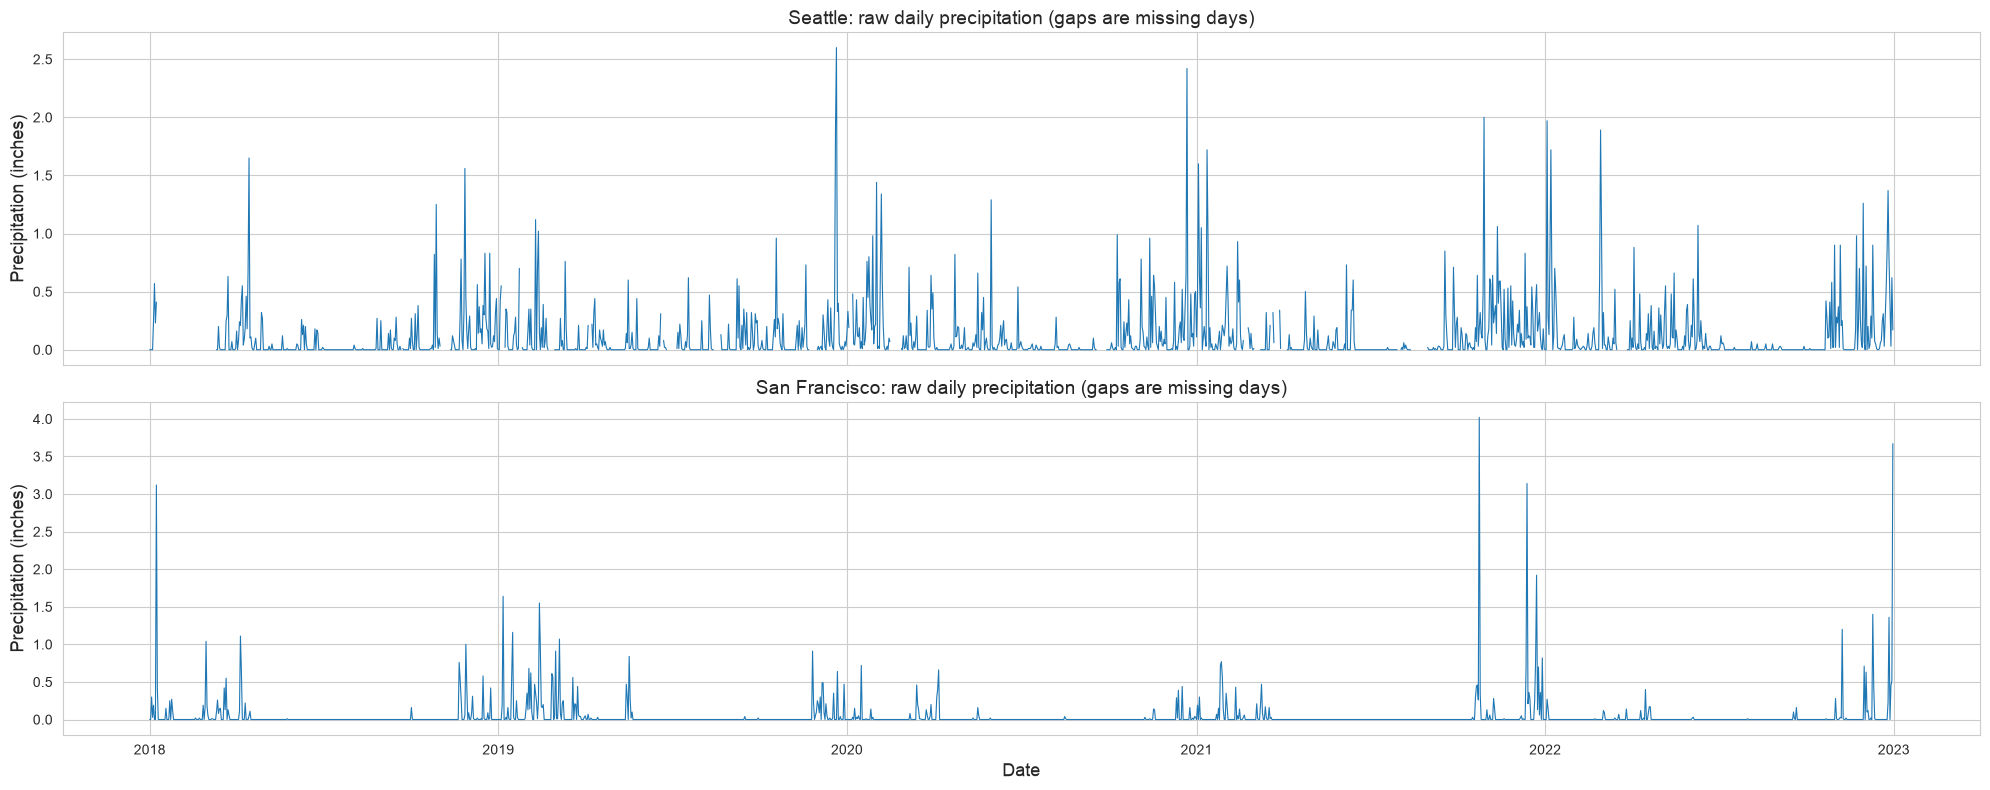

In [14]:
san_francisco_by_date = san_francisco.set_index("DATE")["PRCP"].reindex(full_calendar)

figure, axes = plt.subplots(2, 1, figsize=(20, 8), sharex=True)
for axis, series, city_name in [(axes[0], seattle_by_date, "Seattle"),
                                (axes[1], san_francisco_by_date, "San Francisco")]:
    axis.plot(series.index, series.values, linewidth=0.8)
    axis.set_ylabel("Precipitation (inches)", fontsize=13)
    axis.set_title(f"{city_name}: raw daily precipitation (gaps are missing days)", fontsize=14)
axes[1].set_xlabel("Date", fontsize=13)
plt.tight_layout()
plt.show()

**What the output shows.** Both cities have a strong yearly pattern. Seattle's rain is concentrated in the fall, winter, and spring, and is nearly absent in midsummer. San Francisco has much lower and less frequent rain overall, with a few very large storm days (up to 4.02 inches). The breaks in the Seattle line, especially in early 2018, are the missing days. The data are suitable for the question, but I need a plan for the missing Seattle values.

## Steps 5, 6, and 7: Join the cities, make the data tidy, and rename columns

I rename each city's `PRCP` column to its city label before joining, so the two columns are clear and do not end up with the default `_x` and `_y` suffixes. I join with an **outer join** on the date so every date is kept. San Francisco has all 1,826 dates, so the Seattle days that are absent from its file show up as missing values instead of disappearing.

Then I reshape from wide to long (tidy) format, so that each row is one observation: one city on one day. Finally I rename columns to lowercase names.

In [15]:
wide_precipitation = san_francisco.rename(columns={"PRCP": "SF"}).merge(
    seattle.rename(columns={"PRCP": "SEA"}),
    on="DATE",
    how="outer",
).sort_values("DATE")

print(wide_precipitation.shape)
print(wide_precipitation.isna().sum())
wide_precipitation.head()

(1826, 3)
DATE      0
SF        0
SEA     190
dtype: int64


,DATE,SF,SEA
0,2018-01-01,0.00,0.00
1,2018-01-02,0.00,0.00
2,2018-01-03,0.30,0.00
3,2018-01-04,0.03,0.00
4,2018-01-05,0.19,0.25


In [16]:
precipitation_data = wide_precipitation.melt(
    id_vars="DATE",
    value_vars=["SEA", "SF"],
    var_name="city",
    value_name="precipitation",
).rename(columns={"DATE": "date"})

precipitation_data = precipitation_data.sort_values(["city", "date"], ignore_index=True)

precipitation_data.info()
precipitation_data.head()

<class 'pandas.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           3652 non-null   datetime64[us]
 1   city           3652 non-null   str           
 2   precipitation  3462 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 95.1 KB


,date,city,precipitation
0,2018-01-01,SEA,0.00
1,2018-01-02,SEA,0.00
2,2018-01-03,SEA,0.00
3,2018-01-04,SEA,0.00
4,2018-01-05,SEA,0.25


**What the output shows.** After the outer join there are 1,826 dates, and the only missing values are the 190 Seattle days found earlier. The tidy data frame has 3,652 rows (two cities x 1,826 days) and three columns: `date`, `city`, and `precipitation` (in inches). The 190 missing values are all in the Seattle rows.

## Step 4 (continued): Impute the missing values

Seattle is missing about 10% of its days, including a 62-day stretch, so removing those days would throw away a lot of data and would leave the two cities with different days in the analysis. Instead I impute: each missing Seattle value is replaced by the **mean precipitation for that same calendar day (month and day) across the other years in Seattle's data**. This respects the strong seasonal pattern, which a single overall average would not.

I add `month` and `day` columns for the grouping, and a `was_imputed` flag so imputed values can always be identified later. The grouped mean is computed separately for each city, and then used only where a value is missing. I group by month and day rather than by day of the year number because in a leap year (2020) the day-of-year numbers shift by one after February, which would line up the wrong days.

In [17]:
precipitation_data["month"] = precipitation_data["date"].dt.month
precipitation_data["day"] = precipitation_data["date"].dt.day
precipitation_data["was_imputed"] = precipitation_data["precipitation"].isna()

mean_for_calendar_day = precipitation_data.groupby(["city", "month", "day"])["precipitation"].transform("mean")
precipitation_data["precipitation"] = precipitation_data["precipitation"].fillna(mean_for_calendar_day)

print("Imputed values by city:")
print(precipitation_data.groupby("city")["was_imputed"].sum())
print("\nMissing values remaining:", precipitation_data["precipitation"].isna().sum())

Imputed values by city:
city
SEA    190
SF       0
Name: was_imputed, dtype: int64

Missing values remaining: 0


**What the output shows.** All 190 imputed values are in Seattle, none in San Francisco, and no missing values remain. Every calendar day had at least one observed year to average, so the method could fill every gap.

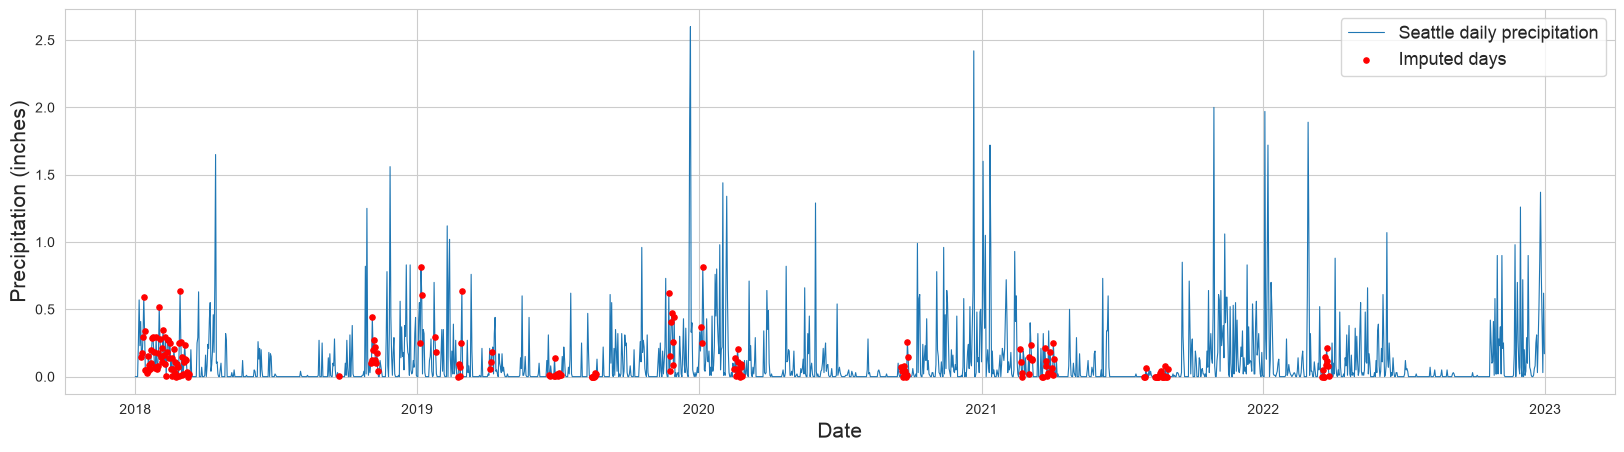

Mean of imputed values:  0.126 inches
Mean of observed values: 0.112 inches


In [18]:
seattle_series = precipitation_data.loc[precipitation_data["city"] == "SEA"]
imputed_days = seattle_series.loc[seattle_series["was_imputed"]]

plt.figure(figsize=(20, 5))
plt.plot(seattle_series["date"], seattle_series["precipitation"], linewidth=0.8, label="Seattle daily precipitation")
plt.scatter(imputed_days["date"], imputed_days["precipitation"], color="red", s=14, zorder=3, label="Imputed days")
plt.xlabel("Date", fontsize=15)
plt.ylabel("Precipitation (inches)", fontsize=15)
plt.legend(fontsize=13)
plt.show()

print("Mean of imputed values: ", round(imputed_days["precipitation"].mean(), 3), "inches")
print("Mean of observed values:", round(seattle_series.loc[~seattle_series["was_imputed"], "precipitation"].mean(), 3), "inches")

**What the output shows.** The red points are the imputed days. They follow the seasonal level, so they are higher in winter and near zero in summer, and they are spread over the gaps, with the long block in early 2018 clearly visible. The average imputed value (about 0.126 inches) is a little higher than the average observed value (about 0.112 inches). That is plausible because many of the gaps fall in the wet season, and the difference is small. One side effect is that an imputed mean is almost never exactly zero, so an imputed day usually counts as a day with some precipitation. I come back to this in the robustness check at the end.

## Step 8: Create derived variables

I add the variables needed for the analysis. `month` and `day` already exist. I add:

* `year`, to compare the cities year by year;
* `any_precipitation`, a True/False flag for days with any precipitation (greater than 0 inches), to measure how often it rains.

I then save the finished tidy data as the clean data file.

In [20]:
precipitation_data["year"] = precipitation_data["date"].dt.year
precipitation_data["any_precipitation"] = precipitation_data["precipitation"] > 0

precipitation_data = precipitation_data[
    ["date", "city", "precipitation", "was_imputed", "year", "month", "day", "any_precipitation"]
]
clean_file = DATA_DIR / "clean_seattle_sf_weather.csv"
precipitation_data.to_csv(clean_file, encoding="utf-8-sig", index=False)

print("Saved:", clean_file)
print(precipitation_data.shape)
precipitation_data.head()

Saved: /Users/amruta/coursework/DATA_5100/weather/data/clean_seattle_sf_weather.csv
(3652, 8)


,date,city,precipitation,was_imputed,year,month,day,any_precipitation
0,2018-01-01,SEA,0.00,False,2018,1,1,False
1,2018-01-02,SEA,0.00,False,2018,1,2,False
2,2018-01-03,SEA,0.00,False,2018,1,3,False
3,2018-01-04,SEA,0.00,False,2018,1,4,False
4,2018-01-05,SEA,0.25,False,2018,1,5,True


**What the output shows.** The clean data has 3,652 rows and 8 columns and is saved as `data/clean_seattle_sf_weather.csv`. This is the file the rest of the notebook uses and the file named in the README.

## Exploratory data analysis

### Daily precipitation for both cities

I start by plotting daily precipitation for both cities on the same graph.

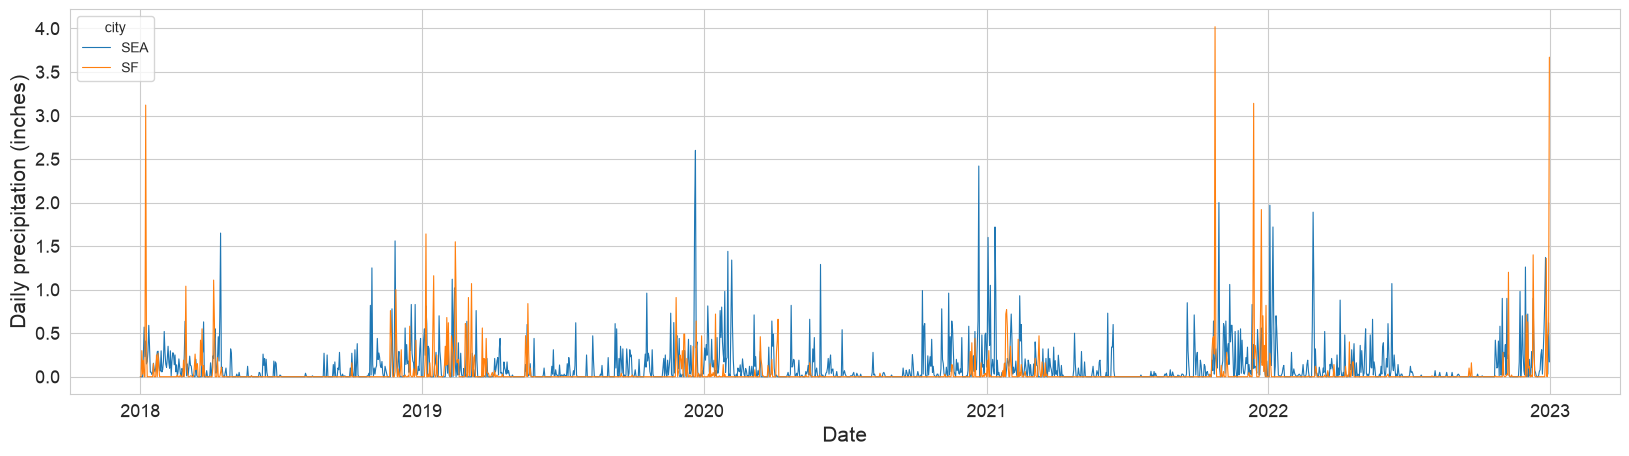

In [21]:
plt.figure(figsize=(20, 5))
sns.lineplot(data=precipitation_data, x="date", y="precipitation", hue="city", linewidth=0.8)
plt.xlabel("Date", fontsize=15)
plt.ylabel("Daily precipitation (inches)", fontsize=15)
plt.tick_params(labelsize=13)
plt.show()

**What the output shows.** Seattle's line is higher more often, and its rainy periods are longer. San Francisco is flat near zero for long stretches, especially in summer, with occasional tall spikes from big storms. A graph of daily values is noisy, so the next steps use summaries.

### Numerical summaries by city

Because `precipitation` holds both cities in one column, I group by city before summarizing.

In [22]:
precipitation_data.groupby("city")["precipitation"].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
SEA,1826.0,0.113,0.241,0.0,0.0,0.01,0.12,2.60
SF,1826.0,0.044,0.220,0.0,0.0,0.00,0.00,4.02


In [23]:
overall_summary = precipitation_data.groupby("city").agg(
    total_inches=("precipitation", "sum"),
    mean_daily_inches=("precipitation", "mean"),
    share_of_days_with_precipitation=("any_precipitation", "mean"),
).round(3)
overall_summary

,total_inches,mean_daily_inches,share_of_days_with_precipitation
city,,,
SEA,206.978,0.113,0.549
SF,80.290,0.044,0.147


**What the output shows.** Over the 1,826 days, Seattle averages about 0.113 inches per day versus 0.044 in San Francisco, which is roughly 2.6 times as much. The median day is 0.01 inches in Seattle and 0.00 in San Francisco, meaning that on a typical San Francisco day nothing falls. In total, this is about 207 inches over five years in Seattle versus about 80 inches in San Francisco. Any precipitation was recorded on about 55% of days in Seattle but only about 15% of days in San Francisco.

### Mean daily precipitation and share of rainy days

The bar graphs below show these two measures for each city. The black line on each bar in the first plot is a 95% confidence interval for the mean.

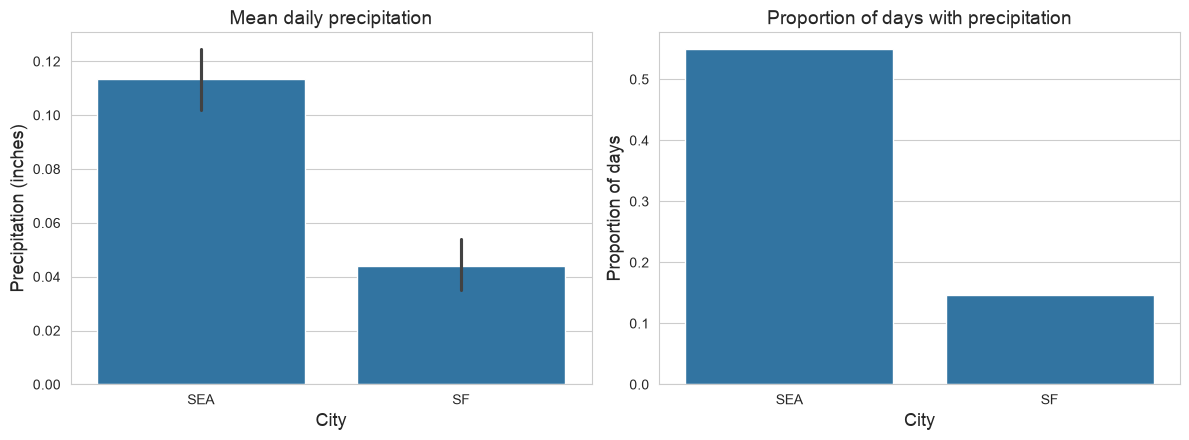

In [24]:
figure, (mean_axis, share_axis) = plt.subplots(1, 2, figsize=(12, 4.5))

sns.barplot(data=precipitation_data, x="city", y="precipitation", ax=mean_axis)
mean_axis.set_title("Mean daily precipitation", fontsize=14)
mean_axis.set_xlabel("City", fontsize=13)
mean_axis.set_ylabel("Precipitation (inches)", fontsize=13)

sns.barplot(data=precipitation_data, x="city", y="any_precipitation", errorbar=None, ax=share_axis)
share_axis.set_title("Proportion of days with precipitation", fontsize=14)
share_axis.set_xlabel("City", fontsize=13)
share_axis.set_ylabel("Proportion of days", fontsize=13)

plt.tight_layout()
plt.show()

**What the output shows.** Seattle's bar is clearly taller on both measures. The confidence intervals on the mean do not overlap, which is the first sign that the difference is real rather than due to chance. The second plot shows the gap in frequency is large: more than half of Seattle days have precipitation compared with fewer than one in six San Francisco days.

### Year by year

A five-year average could be driven by a single unusual year, so I check that the pattern holds each year.

In [25]:
yearly_mean = precipitation_data.pivot_table(
    index="year", columns="city", values="precipitation", aggfunc="mean"
).round(3)
yearly_mean["ratio_sea_to_sf"] = (yearly_mean["SEA"] / yearly_mean["SF"]).round(1)
yearly_mean

city,SEA,SF,ratio_sea_to_sf
year,,,
2018,0.102,0.043,2.4
2019,0.106,0.064,1.7
2020,0.118,0.016,7.4
2021,0.122,0.060,2.0
2022,0.119,0.037,3.2


**What the output shows.** Seattle had higher average daily precipitation than San Francisco in all five years. Seattle is steady, between 0.102 and 0.122 inches per day, while San Francisco varies a lot, from 0.016 inches in 2020 (an unusually dry year, a ratio of about 7 to 1) to 0.064 inches in 2019 (a ratio of about 1.7 to 1). The result does not depend on one odd year.

### Precipitation by month

Both cities have wet and dry seasons, so the next step is to look at each month. A boxplot of the monthly distribution is hard to read with the full range of values because a few storm days are very large, so I zoom in on the 0 to 0.4 inch range.

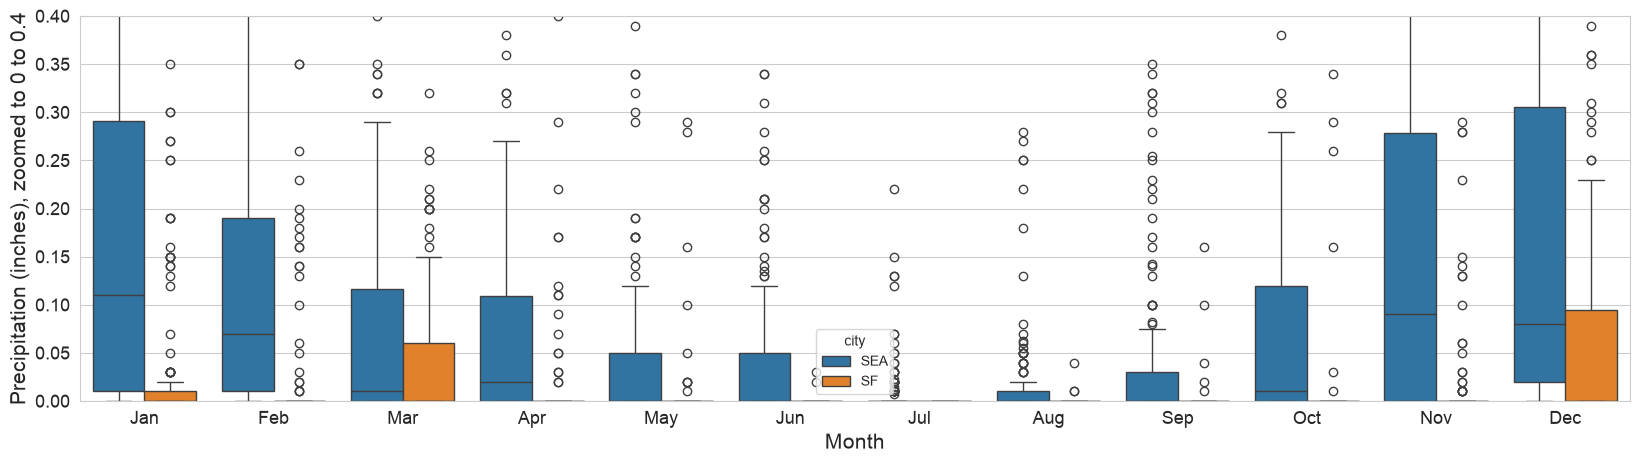

In [26]:
plt.figure(figsize=(20, 5))
sns.boxplot(data=precipitation_data, x="month", y="precipitation", hue="city")
plt.xticks(ticks=range(12), labels=month_names)
plt.ylim(0, 0.4)
plt.xlabel("Month", fontsize=15)
plt.ylabel("Precipitation (inches), zoomed to 0 to 0.4", fontsize=15)
plt.tick_params(labelsize=13)
plt.show()

**What the output shows.** In the zoomed plot, San Francisco's box is squashed at zero from May to October, since most days have no precipitation. Seattle's boxes sit higher than San Francisco's in most months and well above zero in the winter. Many large storm days fall above the 0.4 inch limit of this plot, which is why I also look at monthly means.

In [27]:
monthly_mean = precipitation_data.pivot_table(
    index="month", columns="city", values="precipitation", aggfunc="mean"
).round(3)
monthly_share = precipitation_data.pivot_table(
    index="month", columns="city", values="any_precipitation", aggfunc="mean"
).round(3)

monthly_summary = monthly_mean.join(monthly_share, lsuffix="_mean_inches", rsuffix="_share_of_days")
monthly_summary.index = month_names
monthly_summary

city,SEA_mean_inches,SF_mean_inches,SEA_share_of_days,SF_share_of_days
Jan,0.231,0.090,0.768,0.277
Feb,0.176,0.063,0.816,0.213
Mar,0.090,0.071,0.516,0.361
Apr,0.100,0.032,0.607,0.133
May,0.069,0.015,0.465,0.071
Jun,0.063,0.000,0.447,0.013
Jul,0.014,0.000,0.239,0.000
Aug,0.020,0.000,0.284,0.019
Sep,0.056,0.002,0.380,0.033
Oct,0.118,0.039,0.542,0.058


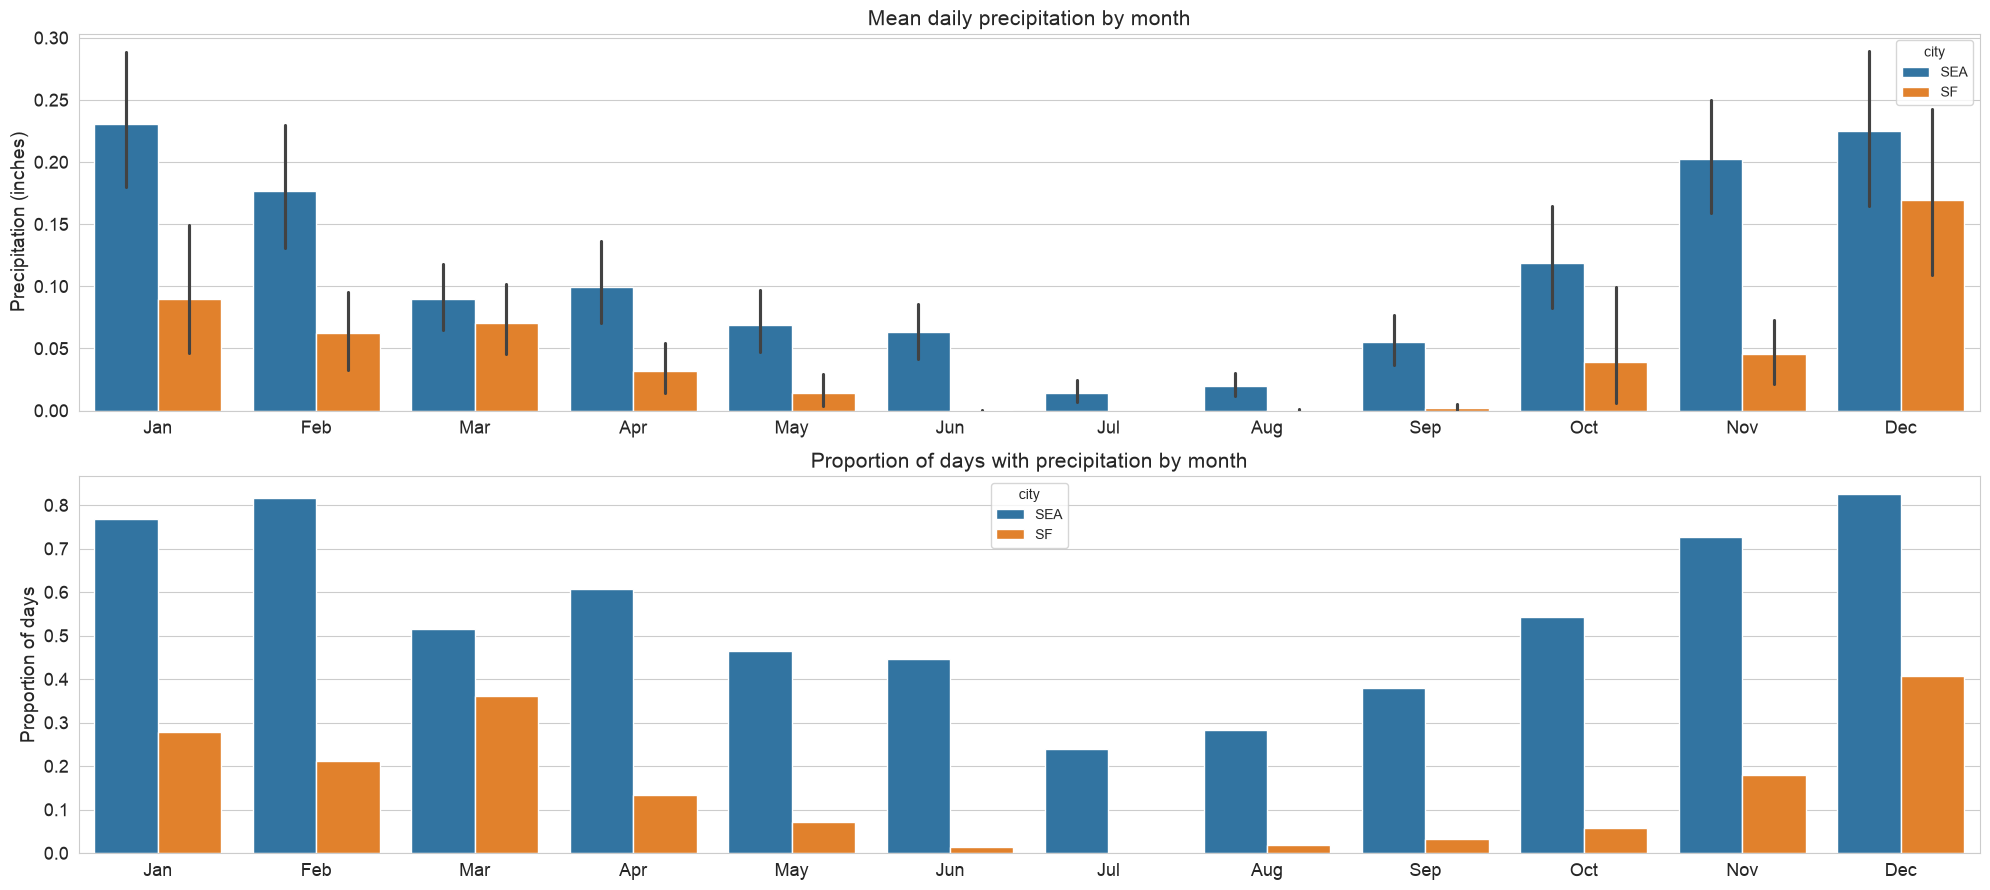

In [28]:
figure, (mean_axis, share_axis) = plt.subplots(2, 1, figsize=(20, 9))

sns.barplot(data=precipitation_data, x="month", y="precipitation", hue="city", ax=mean_axis)
mean_axis.set_title("Mean daily precipitation by month", fontsize=15)
mean_axis.set_ylabel("Precipitation (inches)", fontsize=14)

sns.barplot(data=precipitation_data, x="month", y="any_precipitation", hue="city", errorbar=None, ax=share_axis)
share_axis.set_title("Proportion of days with precipitation by month", fontsize=15)
share_axis.set_ylabel("Proportion of days", fontsize=14)

for axis in (mean_axis, share_axis):
    axis.set_xticks(range(12))
    axis.set_xticklabels(month_names)
    axis.set_xlabel(None)
    axis.tick_params(labelsize=13)

plt.tight_layout()
plt.show()

**What the output shows.** Seattle has higher average daily precipitation than San Francisco in all twelve months. The gap is large from April to November and in January and February (for example, 0.231 versus 0.090 inches per day in January), and it is smallest in March (0.090 versus 0.071) and December (0.225 versus 0.169). The frequency gap is bigger still. From June to September San Francisco almost never records any precipitation (0% to 3% of days), while Seattle still does on about 24% to 45% of days. In winter the gap is also large: in December it rained on about 83% of Seattle days compared with about 41% of San Francisco days.

## Analysis: Are the differences statistically significant?

The graphs suggest Seattle is wetter, but I want to confirm that the differences are not just chance. I test two things for each month, using a significance level of 0.05.

**Amount (Welch's t-test for the mean daily precipitation):**

$$H_0: \mu_{\text{Seattle, month}} = \mu_{\text{San Francisco, month}}$$
$$H_a: \mu_{\text{Seattle, month}} \neq \mu_{\text{San Francisco, month}}$$

**Frequency (two-sample z-test for the proportion of days with any precipitation):**

$$H_0: p_{\text{Seattle, month}} = p_{\text{San Francisco, month}}$$
$$H_a: p_{\text{Seattle, month}} \neq p_{\text{San Francisco, month}}$$

Daily precipitation is skewed (most days are zero), so it does not meet the normality assumption of the t-test. With about 150 days per city in each month the sample is large enough for the t-test to be reasonable, and Welch's version does not assume equal variances. I run the tests for all days first and then month by month.

In [29]:
seattle_precipitation = precipitation_data.loc[precipitation_data["city"] == "SEA"]
san_francisco_precipitation = precipitation_data.loc[precipitation_data["city"] == "SF"]

t_statistic, t_p_value = stats.ttest_ind(
    seattle_precipitation["precipitation"],
    san_francisco_precipitation["precipitation"],
    equal_var=False,
)

days_with_precipitation = [seattle_precipitation["any_precipitation"].sum(),
                           san_francisco_precipitation["any_precipitation"].sum()]
total_days = [len(seattle_precipitation), len(san_francisco_precipitation)]
z_statistic, z_p_value = proportions_ztest(count=days_with_precipitation, nobs=total_days)

print(f"Mean daily precipitation, all days:  t = {t_statistic:.2f}, p = {t_p_value:.2e}")
print(f"Share of days with precipitation:    z = {z_statistic:.2f}, p = {z_p_value:.2e}")

Mean daily precipitation, all days:  t = 9.10, p = 1.41e-19
Share of days with precipitation:    z = 25.49, p = 2.33e-143


**What the output shows.** Over all days, both p-values are far below 0.05 (about 1e-19 for the mean and about 1e-143 for the proportion), and both statistics are positive, which means Seattle is higher. We reject both null hypotheses: Seattle has more precipitation and more days with precipitation than San Francisco.

Now the same two tests for each month separately. I collect the results in a table instead of printing them one by one. I also report a stricter result that divides the significance level by 12 (the Bonferroni correction), because running twelve tests at once makes a false positive more likely.

In [30]:
significance_level = 0.05
bonferroni_level = significance_level / 12

monthly_results = []
for month in range(1, 13):
    seattle_month = seattle_precipitation.loc[seattle_precipitation["month"] == month]
    san_francisco_month = san_francisco_precipitation.loc[san_francisco_precipitation["month"] == month]

    _, mean_p_value = stats.ttest_ind(
        seattle_month["precipitation"], san_francisco_month["precipitation"], equal_var=False
    )
    _, proportion_p_value = proportions_ztest(
        count=[seattle_month["any_precipitation"].sum(), san_francisco_month["any_precipitation"].sum()],
        nobs=[len(seattle_month), len(san_francisco_month)],
    )

    monthly_results.append({
        "month": month_names[month - 1],
        "seattle_mean": seattle_month["precipitation"].mean(),
        "san_francisco_mean": san_francisco_month["precipitation"].mean(),
        "mean_p_value": mean_p_value,
        "seattle_share": seattle_month["any_precipitation"].mean(),
        "san_francisco_share": san_francisco_month["any_precipitation"].mean(),
        "proportion_p_value": proportion_p_value,
    })

monthly_results = pd.DataFrame(monthly_results)
monthly_results["mean_significant"] = monthly_results["mean_p_value"] < significance_level
monthly_results["proportion_significant"] = monthly_results["proportion_p_value"] < significance_level

print("Months with a significant difference in mean precipitation:", monthly_results["mean_significant"].sum(), "of 12")
print("Months with a significant difference in proportion of days: ", monthly_results["proportion_significant"].sum(), "of 12")
print("With Bonferroni correction (0.05 / 12):",
      (monthly_results["mean_p_value"] < bonferroni_level).sum(), "months for the mean and",
      (monthly_results["proportion_p_value"] < bonferroni_level).sum(), "months for the proportion")
print()
monthly_results.round(4)

Months with a significant difference in mean precipitation: 10 of 12
Months with a significant difference in proportion of days:  12 of 12
With Bonferroni correction (0.05 / 12): 9 months for the mean and 11 months for the proportion



,month,seattle_mean,san_francisco_mean,mean_p_value,seattle_share,san_francisco_share,proportion_p_value,mean_significant,proportion_significant
0,Jan,0.2307,0.0899,0.0002,0.7677,0.2774,0.000,True,True
1,Feb,0.1765,0.0627,0.0002,0.8156,0.2128,0.000,True,True
2,Mar,0.0899,0.0705,0.3115,0.5161,0.3613,0.006,False,True
3,Apr,0.0997,0.0318,0.0006,0.6067,0.1333,0.000,True,True
4,May,0.0692,0.0146,0.0003,0.4645,0.0710,0.000,True,True
5,Jun,0.0632,0.0003,0.0000,0.4467,0.0133,0.000,True,True
6,Jul,0.0139,0.0000,0.0029,0.2387,0.0000,0.000,True,True
7,Aug,0.0201,0.0004,0.0001,0.2839,0.0194,0.000,True,True
8,Sep,0.0556,0.0022,0.0000,0.3800,0.0333,0.000,True,True
9,Oct,0.1185,0.0388,0.0186,0.5419,0.0581,0.000,True,True


**What the output shows.** For the amount of precipitation, the difference is significant in 10 of the 12 months. The two exceptions are March (p = 0.31) and December (p = 0.25), the same two months where the averages were closest. For the share of days with precipitation, the difference is significant in all 12 months. In every month where a difference was found, Seattle's value was the higher one, so there is no month where San Francisco is significantly wetter. With the stricter Bonferroni cutoff, 9 months stay significant for the mean and 11 for the proportion, so the overall conclusion is not an artifact of running many tests.

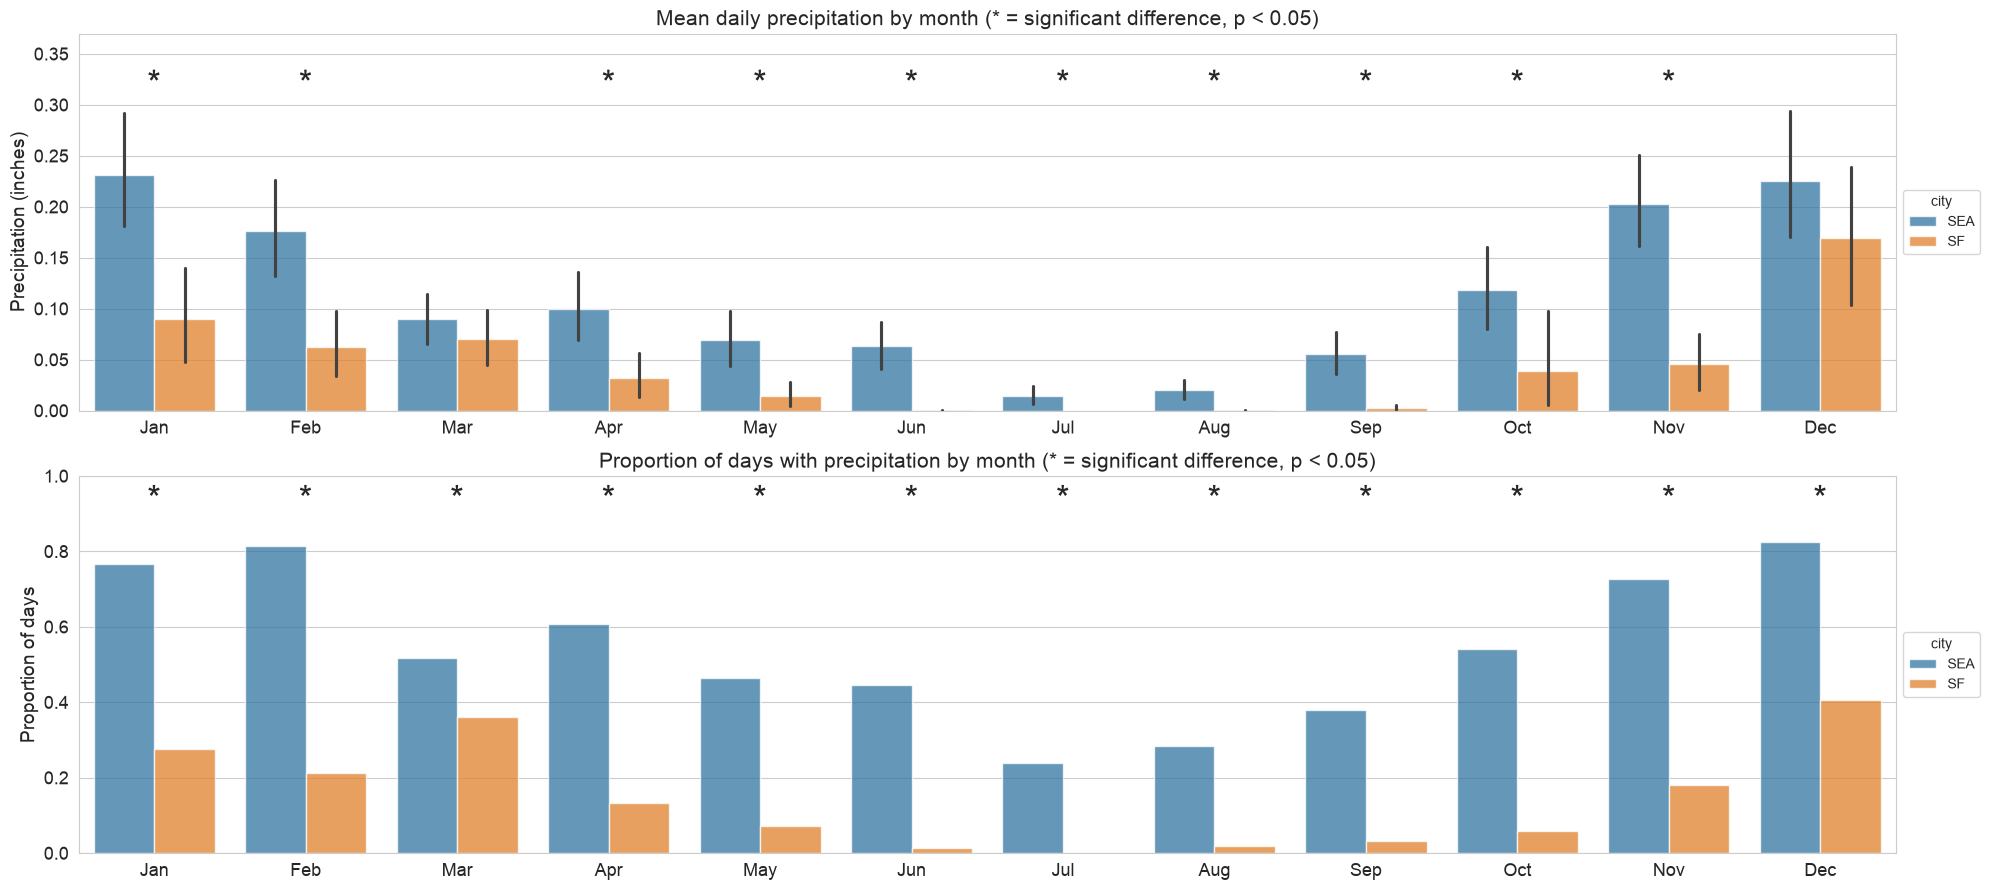

In [31]:
figure, (mean_axis, share_axis) = plt.subplots(2, 1, figsize=(20, 9))

sns.barplot(data=precipitation_data, x="month", y="precipitation", hue="city", alpha=0.75, ax=mean_axis)
mean_axis.set_title("Mean daily precipitation by month (* = significant difference, p < 0.05)", fontsize=15)
mean_axis.set_ylabel("Precipitation (inches)", fontsize=14)

sns.barplot(data=precipitation_data, x="month", y="any_precipitation", hue="city", errorbar=None, alpha=0.75, ax=share_axis)
share_axis.set_title("Proportion of days with precipitation by month (* = significant difference, p < 0.05)", fontsize=15)
share_axis.set_ylabel("Proportion of days", fontsize=14)

mean_axis.set_ylim(0, 0.37)
share_axis.set_ylim(0, 1.0)

for position, row in monthly_results.iterrows():
    if row["mean_significant"]:
        mean_axis.text(position, 0.31, "*", ha="center", fontsize=25)
    if row["proportion_significant"]:
        share_axis.text(position, 0.91, "*", ha="center", fontsize=25)

for axis in (mean_axis, share_axis):
    axis.set_xticks(range(12))
    axis.set_xticklabels(month_names)
    axis.set_xlabel(None)
    axis.tick_params(labelsize=13)
    axis.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), title="city")

plt.tight_layout()
plt.show()

**What the output shows.** A star marks each month with a significant difference. The top panel has stars on every month except March and December, and the bottom panel has a star on all twelve months. This is the monthly picture in one figure: Seattle is wetter all year, and the difference is most uniform in how often it rains.

### Robustness check: using only days with real observations

Imputed values are not real measurements, and an imputed mean is almost never exactly zero, so an imputed day nearly always counts as a day with precipitation. That could make Seattle's share of rainy days look slightly higher than it is. To check, I repeat the headline comparison using only the dates where Seattle has an actual observation, and use the same dates for San Francisco.

In [32]:
observed_dates = seattle_precipitation.loc[~seattle_precipitation["was_imputed"], "date"]
observed_only = precipitation_data.loc[precipitation_data["date"].isin(observed_dates)]

print("Days compared:", observed_dates.nunique())
observed_only.groupby("city").agg(
    mean_daily_inches=("precipitation", "mean"),
    share_of_days_with_precipitation=("any_precipitation", "mean"),
).round(3)

Days compared: 1636


,mean_daily_inches,share_of_days_with_precipitation
city,,
SEA,0.112,0.514
SF,0.044,0.147


**What the output shows.** On the 1,636 days with a real Seattle observation, Seattle averages about 0.112 inches per day versus 0.044 for San Francisco, and it rains on about 51% of Seattle days versus about 15% of San Francisco days. Compared with the imputed analysis (0.113 inches and 55%), the average amount is almost identical and the share of rainy days is about three to four points lower, as expected. The conclusion does not change.

## Conclusion

**Yes, it rains more in Seattle than in San Francisco**, based on these two stations and the 2018 to 2022 period.

* **Amount:** Seattle averages about 0.113 inches of precipitation per day versus 0.044 in San Francisco, about 2.6 times as much (a statistically significant difference, p < 1e-18).
* **Frequency:** Precipitation was recorded on about 55% of days in Seattle versus about 15% in San Francisco (p < 1e-100).
* **Consistency:** Seattle was wetter in each of the five years and in every month of the year. The difference in the share of rainy days is significant in all 12 months. The difference in the amount is significant in 10 months, with March and December being the exceptions.
* **Robustness:** Repeating the comparison on only observed days, without any imputed values, gives nearly identical results.

**Limitations.**

* Each city is represented by a single station, and the two are different kinds of stations (a station in Seattle and an airport station in San Francisco). Rainfall varies within a city, so the results describe these two locations rather than the whole cities.
* Seattle is missing about 10% of its days, including a 62-day gap in early 2018, which I filled in with calendar-day averages. Imputed values are estimates, not measurements.
* Five years is a short period for a climate question, and 2020 was unusually dry in San Francisco.
* The tests treat each day as independent, but weather on consecutive days is related, so the p-values are probably smaller than the true uncertainty. The differences are large enough that the conclusion is not in doubt.
* Precipitation here is whatever the station measured, so it is not strictly limited to liquid rain.

The clean, analysis-ready data is saved in `data/clean_seattle_sf_weather.csv`.